<a href="https://colab.research.google.com/github/mohamadfaisalbashir/Practical-Statistics-for-Data-Scientists/blob/main/07_Unsupervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Unsupervised Learning**

This notebook covers Unsupervised Learning:
1. Principal Components Analysis (PCA)
2. K-Means Clustering
3. Hierarchical Clustering
4. Model-Based Clustering
5. Scaling and Categorical Variables
6. Summary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

np.random.seed(42)

SP500_DATA_CSV = 'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/sp500_data.csv.gz'
SP500_SECTORS_CSV = 'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/sp500_sectors.csv'

sp500_px = pd.read_csv(SP500_DATA_CSV, index_col=0)
sp500_sym = pd.read_csv(SP500_SECTORS_CSV)

syms = sp500_sym[sp500_sym['sector'].isin(['information_technology', 'energy'])]['symbol']
data_subset = sp500_px.loc[sp500_px.index >= '2011-01-01', syms]

print("Pustaka dan Dataset SP500 berhasil dimuat untuk Analisis Unsupervised.")

Pustaka dan Dataset SP500 berhasil dimuat untuk Analisis Unsupervised.


## **1. Principal Components Analysis (PCA)**

In the era of Big Data, datasets frequently possess hundreds or thousands of features (high dimensionality). This introduces extreme computational complexity and the 'Curse of Dimensionality', where distances between points become mathematically meaningless.

Principal Components Analysis (PCA) is a rigorous mathematical technique for dimensionality reduction. It fundamentally transforms the original, correlated features into a smaller set of entirely new, uncorrelated variables called Principal Components. The first principal component is the mathematical vector that captures the absolute maximum amount of variance in the data. The second component is entirely orthogonal (perpendicular) to the first and captures the maximum remaining variance, and so on. By retaining only the first few components, a data scientist can compress a 100-variable dataset into just 3 or 4 variables while intentionally preserving the vast majority of the underlying statistical information.

In [2]:
oil_px = data_subset[['CVX', 'XOM']]
pca = PCA(n_components=2)
pca.fit(oil_px)

loadings = pd.DataFrame(pca.components_, columns=oil_px.columns, index=['PC1', 'PC2'])
print("Bobot (Loadings) Komponen Utama:")
print(loadings)

print(f"\nVarians yang dijelaskan oleh PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"Varians yang dijelaskan oleh PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")

Bobot (Loadings) Komponen Utama:
          CVX       XOM
PC1  0.828674  0.559732
PC2 -0.559732  0.828674

Varians yang dijelaskan oleh PC1: 89.09%
Varians yang dijelaskan oleh PC2: 10.91%


## **2. K-Means Clustering**

Clustering is the process of partitioning a dataset into distinct, non-overlapping subgroups (clusters) where the data points within a cluster are highly similar to each other, and highly dissimilar to points in other clusters.

K-Means is the most ubiquitous clustering algorithm. The analyst must strictly specify the number of desired clusters, *K*, a priori. The algorithm operates via an iterative optimization process (Lloyd's algorithm): it randomly places *K* centroids in the feature space, assigns every data point to the nearest centroid (minimizing within-cluster sum of squares), and then recalculates the new centroid based on the mean of the assigned points. This continuous cycle of assignment and recalculation halts only when the centroids geometrically stabilize and cease moving. However, K-Means is highly sensitive to the initial random placement of centroids and demands that all features be geometrically scaled.

In [3]:
kmeans_data = data_subset[['AAPL', 'MSFT', 'CVX', 'XOM', 'SLB']].dropna()

scaler = StandardScaler()
kmeans_data_scaled = scaler.fit_transform(kmeans_data)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(kmeans_data_scaled)

centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=kmeans_data.columns)
print("Pusat Klaster K-Means (Rata-rata Return Harian):")
print(centers)

Pusat Klaster K-Means (Rata-rata Return Harian):
       AAPL      MSFT       CVX       XOM       SLB
0  0.470291  0.301991  1.053019  0.819661  1.132046
1 -0.809679 -0.269403 -1.224396 -0.870023 -1.297335
2  0.595424  0.143667 -0.174230 -0.070070 -0.234015
3 -0.633292 -0.156033  0.162792  0.118557  0.125589


## **3. Hierarchical Clustering**

K-Means forces the user to arbitrarily guess the optimal number of clusters (*K*). Hierarchical clustering eliminates this assumption by constructing a deeply detailed, tree-like hierarchy of clusters, visualizable as a 'Dendrogram'.

The most common approach is Agglomerative (bottom-up) clustering. The algorithm begins by treating every single individual observation in the dataset as its own distinct cluster. It then mathematically scans for the two closest, most similar clusters and merges them. This iterative merging process continues until all data points are fused into one massive, single cluster. By evaluating the Dendrogram, the data scientist can visually observe the natural geometry of the data and explicitly choose where to 'cut' the tree to form the final clusters, bypassing the rigid requirement of pre-defining *K*.

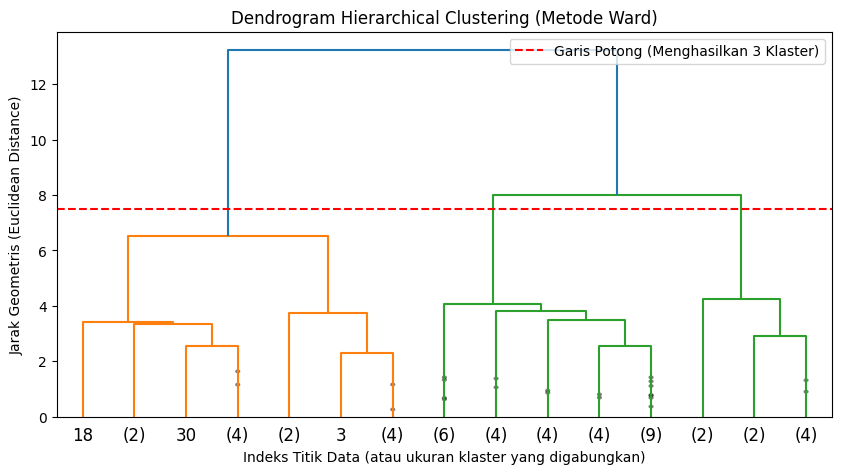

In [4]:
hier_data = kmeans_data_scaled[:50]

Z = linkage(hier_data, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode='lastp', p=15, show_contracted=True)
plt.title('Dendrogram Hierarchical Clustering (Metode Ward)')
plt.xlabel('Indeks Titik Data (atau ukuran klaster yang digabungkan)')
plt.ylabel('Jarak Geometris (Euclidean Distance)')
plt.axhline(y=7.5, color='r', linestyle='--', label='Garis Potong (Menghasilkan 3 Klaster)')
plt.legend()
plt.show()

## **4. Model-Based Clustering**

Both K-Means and Hierarchical clustering rely on rigid, geometric distance metrics (like Euclidean distance). They force observations into clusters with hard boundaries. Model-Based Clustering takes a sophisticated statistical approach, assuming that the data was generated by a mixture of distinct, underlying probability distributions (most commonly, multivariate Gaussian/normal distributions).

Gaussian Mixture Models (GMM) are the primary tool here. Instead of finding geometric centers, GMM utilizes the Expectation-Maximization (EM) algorithm to estimate the mean and covariance of these hidden statistical distributions. Crucially, GMM provides 'soft clustering'. It does not definitively state 'Point A belongs to Cluster 1'. Instead, it outputs a precise probability: 'Point A has a 70% probability of belonging to Gaussian distribution 1, and a 30% probability of belonging to Gaussian distribution 2'. This accommodates overlapping clusters and elliptical shapes far better than the rigid, spherical clusters produced by K-Means.

In [6]:
gmm = GaussianMixture(n_components=4, random_state=42, n_init=10)
gmm.fit(kmeans_data_scaled)

probabilities = gmm.predict_proba(kmeans_data_scaled)

print("Probabilitas Keanggotaan Klaster (5 Observasi Pertama):")
print(pd.DataFrame(probabilities[:5], columns=['Klaster 1', 'Klaster 2', 'Klaster 3', 'Klaster 4']).round(3))

Probabilitas Keanggotaan Klaster (5 Observasi Pertama):
   Klaster 1  Klaster 2  Klaster 3  Klaster 4
0      0.232      0.664      0.098      0.006
1      0.002      0.878      0.084      0.036
2      0.090      0.850      0.015      0.044
3      0.001      0.040      0.628      0.331
4      0.279      0.694      0.021      0.007


## **5. Scaling and Categorical Variables**

Unsupervised learning algorithms are profoundly fragile mathematically. Because K-Means, PCA, and Hierarchical clustering rely almost exclusively on calculating geometric distances (Euclidean or Manhattan) or analyzing variance, unscaled data will catastrophically destroy the model. A variable with large intrinsic numerical values (like housing prices in the millions) will monopolize the distance calculation, rendering smaller variables (like interest rates in decimals) entirely invisible to the algorithm. Therefore, aggressive Standardization (Z-scores) or Normalization (Min-Max scaling) is a strict mandatory prerequisite.

Furthermore, classical distance metrics are designed strictly for continuous numerical data. Integrating categorical variables (like Zip Code or Color) into clustering requires extreme caution. Standard dummy encoding introduces asymmetrical binary distances that often distort K-Means. To robustly handle categorical data in unsupervised models, data scientists must utilize specialized distance metrics, such as Gower's distance, which elegantly computes similarity across mixed data types.

## **6. Summary**

Chapter 7 completes our statistical journey by removing the guardrails of the target variable. Unsupervised learning requires the data scientist to trust the mathematics of geometry, variance, and probability to reveal what the human eye cannot perceive in high-dimensional space.

Principal Components Analysis (PCA) tames the chaos of hundreds of variables by mathematically projecting the data into its most informative dimensions. K-Means provides rapid, rigid grouping based on geometric centers, while Hierarchical Clustering offers a meticulous, visual map of natural data affinities. Finally, Model-Based Clustering (GMM) acknowledges the messy reality of data by using statistical probability to manage overlapping boundaries. While supervised learning answers the question "What will happen?", unsupervised learning answers the far more profound question: "What underlying structure truly exists here?"